# 🏥 Medical GRAM-CLIP: Hybridizing Architectures for Medical Image-Text Retrieval

*Authors*:

- Flavio Ialongo - Student ID: 2000932
- Francesco Barbetta - Student ID: 1991907
- Marco Antonio Iossa - Student ID: 2001300


## 🎯 1. Project Aim & Selected Papers

The primary objective of this project is to explore and improve the capabilities of Vision-Language Models (VLMs) in the medical domain, specifically focusing on the task of Image-Text Retrieval. 

We draw inspiration from two foundational papers:
1. **MedCLIP**: This paper demonstrates the effectiveness of decoupling images and texts using "semantic soft-targets" derived from clinical semantic similarity to overcome the false-negative limitation in standard InfoNCE when applied to medical datasets. *Note: In our implementation, we use a simpler version of MedCLIP where semantic targets are generated directly from the text embeddings of a frozen language encoder rather than UMLS-based clinical entity matching.*
2. **GRAM**: This paper proposes a framework to mitigate representation collapse in medical models by preserving semantic topology and introducing a "volume computation" in the contrastive objective.

**Our Contribution (GRAM-Med)**: We developed a hybridized architecture. We integrated the semantic soft-targets logic (from our simplified MedCLIP) into a contrastive loss framework inspired by GRAM.


## 🧠 2. Theoretical Background and Key Concepts

- **InfoNCE Loss and False Negatives**: In classic VLMs like CLIP, the InfoNCE loss aligns each image strictly with its paired report (hard-target), repelling all other reports in the batch. In the medical domain, this is detrimental: two different patients with the same pathology will have similar reports but will be treated as "negatives" to each other, forcing the model to learn meaningless patient-specific artifacts.
- **Semantic Soft-Targets (Simplified MedCLIP)**: To solve this, we use a simpler version of MedCLIP compared to the original paper. Rather than extracting clinical entities using external medical vocabularies, we compute a semantic similarity matrix directly using the text embeddings of a frozen text feature extractor (*PubMedBERT*) for all texts in the batch. This generates soft probabilities ("soft-targets") instructing the model: "Do not penalize the retrieval if the image retrieves a report that is semantically similar to the original one".


In [3]:
%pip install torch torchvision transformers datasets accelerate huggingface_hub matplotlib scikit-learn pandas tqdm pillow timm python-dotenv



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
from __future__ import annotations
import os
import sys
import json
from typing import Dict, Iterable, Any, List, Tuple, Callable, Optional
from dataclasses import dataclass
from pathlib import Path
import torch
from torch import nn
from torch.nn import functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, random_split
from datasets import load_dataset
from PIL import Image
from transformers import AutoImageProcessor, AutoTokenizer
from transformers import AutoModel
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import timm
from torchvision import transforms
from IPython.display import display, Markdown
from dataclasses import asdict

2026-07-21 21:04:15.457652: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 21:04:15.465545: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784660655.474203   43562 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784660655.476774   43562 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-21 21:04:15.486925: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## ⚙️ 3. Implementation Details
### 3.1 Dataset (`dataset.py`)

In [5]:
class MIMICCXRDataset(Dataset):
    """
    Dataset wrapper for MIMIC-CXR from Hugging Face.

    Each item returns:
        {
            "image": PIL image,
            "text": report string
        }
    """

    def __init__(
        self,
        split: str = "train",
        dataset_name: str = "MLforHealthcare/mimic-cxr",
    ) -> None:
        super().__init__()


        self.data = load_dataset(
            dataset_name,
            split=split,
        )

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        item = self.data[idx]

        image = item["image"]
        text = item["reports"]

        if isinstance(text, list):
            text = " ".join(str(t) for t in text)

        if text is None:
            text = ""

        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)

        image = image.convert("RGB")

        return {
            "image": image,
            "text": str(text),
        }


class MedicalCollator:
    """
    Collator for the DataLoader.

    It converts:
    - PIL images into ViT pixel_values
    - report strings into tokenizer input_ids and attention_mask
    """

    def __init__(
        self,
        vision_model_name: str = "google/vit-base-patch16-224",
        text_model_name: str = "NeuML/pubmedbert-base-embeddings",
        max_length: int = 256,
        vision_model_type: str = "vit",
    ) -> None:
        self.vision_model_type = vision_model_type

        if self.vision_model_type == "cnn":
            import timm
            from torchvision import transforms
            model_config = timm.data.resolve_model_data_config(vision_model_name)
            self.image_transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=model_config["mean"], std=model_config["std"]),
            ])
        else:
            self.image_processor = AutoImageProcessor.from_pretrained(vision_model_name, use_fast=True)

        self.tokenizer = AutoTokenizer.from_pretrained(text_model_name)
        self.max_length = max_length

    def __call__(self, batch: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images = [sample["image"] for sample in batch]
        texts = [sample["text"] for sample in batch]

        if self.vision_model_type == "cnn":
            image_tensors = [self.image_transform(img) for img in images]
            pixel_values = torch.stack(image_tensors)
        else:
            image_inputs = self.image_processor(
                images=images,
                return_tensors="pt",
            )
            pixel_values = image_inputs["pixel_values"]

        text_inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "images": pixel_values,
            "input_ids": text_inputs["input_ids"],
            "attention_mask": text_inputs["attention_mask"],
        }

### 3.2 Model Architecture (`model.py`)

Our architecture is a **Dual-Encoder** design consisting of:
1. **Vision Encoder**: We experiment with two backbone architectures to compare their representations: a Transformer-based model (**ViT-Base**) and a Convolutional neural network (**ResNet34**).
2. **Text Encoder**: We use a pre-trained, frozen **PubMedBERT** model. Unlike standard CLIP which trains the text encoder from scratch, we freeze this encoder and use its embeddings to generate our semantic soft-targets and compare them against the projected image features.

Both modalities are projected into a shared semantic space using linear projection heads.

![Model Architecture](architecture.jpg)

In [6]:
class MedicalMultimodal(nn.Module):
    def __init__(
        self,
        vision_model_name: str = "google/vit-base-patch16-224",
        text_model_name: str = "NeuML/pubmedbert-base-embeddings",
        projection_dim: int = 512,
        vision_model_type: str = "vit",
        gradient_checkpointing: bool = False,
    ) -> None:
        super().__init__()

        self.vision_model_type = vision_model_type

        if self.vision_model_type == "cnn":
            import timm
            self.vision_encoder = timm.create_model(vision_model_name, pretrained=True, num_classes=0)
            vision_hidden_dim = self.vision_encoder.num_features
        else:
            self.vision_encoder = AutoModel.from_pretrained(vision_model_name)
            vision_hidden_dim = 768

        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        
        if gradient_checkpointing:
            if hasattr(self.vision_encoder, "set_grad_checkpointing"):
                self.vision_encoder.set_grad_checkpointing(True)
            elif hasattr(self.vision_encoder, "gradient_checkpointing_enable"):
                self.vision_encoder.gradient_checkpointing_enable()
            self.text_encoder.gradient_checkpointing_enable()
            
        # Instantiate a separate, completely frozen text encoder specifically to 
        # generate stable ground truth semantic targets, preventing target collapse.
        self.target_text_encoder = AutoModel.from_pretrained(text_model_name)
        self.target_text_encoder.eval()
        for param in self.target_text_encoder.parameters():
            param.requires_grad = False

        text_hidden_dim = 768
        self.image_projector = nn.Linear(vision_hidden_dim, projection_dim)
        self.text_projector = nn.Linear(text_hidden_dim, projection_dim)
        self.logit_scale = nn.Parameter(torch.tensor(1 / 0.07).log())

    def freeze_encoders(self, vision_layers_unfrozen: int = 1, text_layers_unfrozen: int = 2) -> None:
        for param in self.vision_encoder.parameters():
            param.requires_grad = False

        for param in self.text_encoder.parameters():
            param.requires_grad = False

        if vision_layers_unfrozen == -1:
            for param in self.vision_encoder.parameters():
                param.requires_grad = True
        elif self.vision_model_type == "vit":
            # ViT encoder blocks
            if hasattr(self.vision_encoder, "encoder"):
                for block in self.vision_encoder.encoder.layer[-vision_layers_unfrozen:]:
                    for param in block.parameters():
                        param.requires_grad = True
        elif self.vision_model_type == "cnn":
            if vision_layers_unfrozen > 0:
                children = list(self.vision_encoder.children())
                for child in children[-vision_layers_unfrozen:]:
                    for param in child.parameters():
                        param.requires_grad = True

        if text_layers_unfrozen == -1:
            for param in self.text_encoder.parameters():
                param.requires_grad = True
        # BERT encoder blocks
        elif hasattr(self.text_encoder, "encoder"):
            for block in self.text_encoder.encoder.layer[-text_layers_unfrozen:]:
                for param in block.parameters():
                    param.requires_grad = True

        for param in self.image_projector.parameters():
            param.requires_grad = True
            
        for param in self.text_projector.parameters():
            param.requires_grad = True

        self.logit_scale.requires_grad = True

    def encode_image(self, images: torch.Tensor) -> torch.Tensor:
        if self.vision_model_type == "cnn":
            cls = self.vision_encoder(images)
        else:
            outputs = self.vision_encoder(pixel_values=images)
            cls = outputs.last_hidden_state[:, 0]
            
        projected = self.image_projector(cls)
        return F.normalize(projected, dim=-1)

    def encode_text(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0]
        projected = self.text_projector(cls)
        return F.normalize(projected, dim=-1)

    def forward(
        self,
        images: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> Dict[str, torch.Tensor]:
        image_embeds = self.encode_image(images)
        
        # The active text encoder being fine-tuned and projected
        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        active_text_cls = text_outputs.last_hidden_state[:, 0]
        projected_text = self.text_projector(active_text_cls)
        text_embeds = F.normalize(projected_text, dim=-1)

        # The frozen target text encoder for stable ground truth semantics
        with torch.no_grad():
            target_outputs = self.target_text_encoder(input_ids=input_ids, attention_mask=attention_mask)
            raw_text_cls = target_outputs.last_hidden_state[:, 0]

        return {
            "image_embeds": image_embeds,
            "text_embeds": text_embeds,
            "raw_text_embeds": F.normalize(raw_text_cls, dim=-1),
            "logit_scale": self.logit_scale.exp().clamp(max=100),
        }


### 3.3 Loss Functions (`losses.py`)
This file is the mathematical core of the project. It implements the `LossRouter`, which dynamically selects the training objective.
We implemented the standard symmetric InfoNCE loss (`clip`), a simplified version of `medclip` (where soft targets are generated by text embeddings), and our hybridized `gram_med` loss.

![Contrastive Target Matrices Comparison](matrix_loss.png)
*Figure 1: Target Matrices Comparison between standard InfoNCE (Hard Targets) and MedCLIP/GRAM-Med (Semantic Soft Targets normalized via Softmax).*

Below is the exact implementation of the loss functions:


The volume_computation function comes from the original paper's repository: https://github.com/ispamm/GRAM

In [7]:
def volume_computation(language, *inputs):
    """
    General function to compute volume for contrastive learning loss functions.
    Compute the volume metric for each vector in language batch and all the other modalities listed in *inputs.

    Args:
    - language (torch.Tensor): Tensor of shape (batch_size1, dim)
    - *inputs (torch.Tensor): Variable number of tensors of shape (batch_size2, dim)

    Returns:
    - torch.Tensor: Tensor of shape (batch_size1, batch_size2) representing the volume for each pair.
    """
    batch_size1 = language.shape[0]
    batch_size2 = inputs[0].shape[0]

    # Compute pairwise dot products for language with itself
    ll = torch.einsum('bi,bi->b', language, language).unsqueeze(1).expand(-1, batch_size2)

    # Compute pairwise dot products for language with each input
    l_inputs = [language @ input.T for input in inputs]

    # Compute pairwise dot products for each input with themselves and with each other
    input_dot_products = []
    for i, input1 in enumerate(inputs):
        row = []
        for j, input2 in enumerate(inputs):
            dot_product = torch.einsum('bi,bi->b', input1, input2).unsqueeze(0).expand(batch_size1, -1)
            row.append(dot_product)
        input_dot_products.append(row)

    # Stack the results to form the Gram matrix for each pair
    G = torch.stack([
        torch.stack([ll] + l_inputs, dim=-1),
        *[torch.stack([l_inputs[i]] + input_dot_products[i], dim=-1) for i in range(len(inputs))]
    ], dim=-2)

    # Compute the determinant for each Gram matrix
    gram_det = torch.det(G.float())

    # Compute the square root of the absolute value of the determinants
    res = torch.sqrt(torch.abs(gram_det) + 1e-8)
    return res


In [8]:
class ClipInfoNCELoss(nn.Module):
    """
    Standard CLIP symmetric InfoNCE loss.

    It computes:
    - image-to-text contrastive loss
    - text-to-image contrastive loss

    The final loss is the average of the two.
    """

    def forward(
        self,
        image_embeds: torch.Tensor,
        text_embeds: torch.Tensor,
        logit_scale: torch.Tensor,
    ) -> torch.Tensor:
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)

        logits_per_image = logit_scale * image_embeds @ text_embeds.T
        logits_per_text = logits_per_image.T

        labels = torch.arange(image_embeds.size(0), device=image_embeds.device)

        loss_i2t = F.cross_entropy(logits_per_image, labels)
        loss_t2i = F.cross_entropy(logits_per_text, labels)

        return 0.5 * (loss_i2t + loss_t2i)


class GramLossAdapter(nn.Module):
    """
    Adapter for the official GRAM repository.

    This adapter imports the volume_computation function from gram_utils.
    """

    def __init__(
        self,
        contrastive_temp: float = 0.07,
        label_smoothing: float = 0.1,
    ) -> None:
        super().__init__()

        self.contrastive_temp = contrastive_temp
        self.label_smoothing = label_smoothing
        
        try:
            self.volume_computation = volume_computation
        except ImportError:
            self.volume_computation = lambda i, t: -(i @ t.T)
            print("[WARNING] gram_utils not found. Using dot-product fallback for GRAM.", flush=True)

    def forward(
        self,
        image_embeds: torch.Tensor,
        text_embeds: torch.Tensor,
        logit_scale: torch.Tensor,
    ) -> torch.Tensor:
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)

        volume = self.volume_computation(image_embeds, text_embeds)
        scaled_neg_volume = -volume * logit_scale

        scaled_neg_volume_t = scaled_neg_volume.T

        batch_size = image_embeds.size(0)
        targets = torch.arange(batch_size, device=image_embeds.device)

        loss_i2t = F.cross_entropy(
            scaled_neg_volume,
            targets,
            label_smoothing=self.label_smoothing,
        )

        loss_t2i = F.cross_entropy(
            scaled_neg_volume_t,
            targets,
            label_smoothing=self.label_smoothing,
        )

        return 0.5 * (loss_i2t + loss_t2i)

class MedClipLoss(nn.Module):
    """
    MedCLIP loss variant that computes semantic similarity from the text 
    embeddings themselves to form soft targets, preventing false negatives.
    """

    def __init__(self, target_temp: float = 0.1) -> None:
        super().__init__()
        self.target_temp = target_temp

    def forward(
        self,
        image_embeds: torch.Tensor,
        text_embeds: torch.Tensor,
        logit_scale: torch.Tensor,
        raw_text_embeds: torch.Tensor,
    ) -> torch.Tensor:
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)
        raw_text_embeds = F.normalize(raw_text_embeds, dim=-1)

        logits_per_image = logit_scale * image_embeds @ text_embeds.T
        logits_per_text = logits_per_image.T

        # Soft targets based on RAW text similarity (prevents moving target collapse)
        sim_text = raw_text_embeds @ raw_text_embeds.T
        targets = F.softmax(sim_text / self.target_temp, dim=-1)

        loss_i2t = F.cross_entropy(logits_per_image, targets)
        loss_t2i = F.cross_entropy(logits_per_text, targets)

        return 0.5 * (loss_i2t + loss_t2i)


class GramMedLoss(nn.Module):
    """
    GramMed loss: Combines GRAM volume computation with MedCLIP's logic
    of using soft targets derived from text semantic similarities.
    """

    def __init__(
        self,
        contrastive_temp: float = 0.07,
        target_temp: float = 0.1,
    ) -> None:
        super().__init__()

        self.contrastive_temp = contrastive_temp
        self.target_temp = target_temp
        
        try:
            self.volume_computation = volume_computation
        except ImportError:
            self.volume_computation = lambda i, t: -(i @ t.T)
            print("[WARNING] gram_utils not found. Using dot-product fallback for GRAM.", flush=True)

    def forward(
        self,
        image_embeds: torch.Tensor,
        text_embeds: torch.Tensor,
        logit_scale: torch.Tensor,
        raw_text_embeds: torch.Tensor,
    ) -> torch.Tensor:
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)
        raw_text_embeds = F.normalize(raw_text_embeds, dim=-1)

        volume = self.volume_computation(image_embeds, text_embeds)
        scaled_neg_volume = -volume * logit_scale

        scaled_neg_volume_t = scaled_neg_volume.T

        # Soft targets from stable RAW text embeddings similarity
        sim_text = raw_text_embeds @ raw_text_embeds.T
        targets = F.softmax(sim_text / self.target_temp, dim=-1)

        loss_i2t = F.cross_entropy(scaled_neg_volume, targets)
        loss_t2i = F.cross_entropy(scaled_neg_volume_t, targets)

        return 0.5 * (loss_i2t + loss_t2i)


class LossRouter(nn.Module):
    """
    Selects which loss to use.

    Available loss types:
    - clip
    - gram
    - medclip
    - gram_med
    """

    def __init__(
        self,
        loss_type: str,
        contrastive_temp: float = 0.07,
        target_temp: float = 0.1,
    ) -> None:
        super().__init__()

        if loss_type not in {"clip", "gram", "medclip", "gram_med"}:
            raise ValueError(
                "loss_type must be one of: 'clip', 'gram', 'medclip', or 'gram_med'."
            )

        self.loss_type = loss_type

        self.clip_loss: Optional[ClipInfoNCELoss] = None
        self.gram_loss: Optional[GramLossAdapter] = None
        self.medclip_loss: Optional[MedClipLoss] = None
        self.gram_med_loss: Optional[GramMedLoss] = None

        if loss_type == "clip":
            self.clip_loss = ClipInfoNCELoss()

        elif loss_type == "gram":
            self.gram_loss = GramLossAdapter(
                contrastive_temp=contrastive_temp,
            )

        elif loss_type == "medclip":
            self.medclip_loss = MedClipLoss(target_temp=target_temp)

        elif loss_type == "gram_med":
            self.gram_med_loss = GramMedLoss(
                contrastive_temp=contrastive_temp,
                target_temp=target_temp,
            )

    def forward(
        self,
        image_embeds: torch.Tensor,
        text_embeds: torch.Tensor,
        logit_scale: torch.Tensor,
        raw_text_embeds: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        if self.loss_type == "clip":
            assert self.clip_loss is not None
            return self.clip_loss(
                image_embeds=image_embeds,
                text_embeds=text_embeds,
                logit_scale=logit_scale,
            )

        if self.loss_type == "gram":
            assert self.gram_loss is not None
            return self.gram_loss(
                image_embeds=image_embeds,
                text_embeds=text_embeds,
                logit_scale=logit_scale,
            )

        if self.loss_type == "medclip":
            assert self.medclip_loss is not None
            assert raw_text_embeds is not None
            return self.medclip_loss(
                image_embeds=image_embeds,
                text_embeds=text_embeds,
                logit_scale=logit_scale,
                raw_text_embeds=raw_text_embeds,
            )

        if self.loss_type == "gram_med":
            assert self.gram_med_loss is not None
            assert raw_text_embeds is not None
            return self.gram_med_loss(
                image_embeds=image_embeds,
                text_embeds=text_embeds,
                logit_scale=logit_scale,
                raw_text_embeds=raw_text_embeds,
            )

        raise RuntimeError(f"Unknown loss_type: {self.loss_type}")


### 3.4 Evaluation Metrics (`eval.py`)

In [9]:
@torch.no_grad()
def extract_embeddings(
    model, 
    dataloader, 
    device: torch.device
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    model.eval()
    image_embeddings = []
    text_embeddings = []
    raw_text_embeddings = []

    for batch in tqdm(dataloader, desc="Extracting embeddings"):
        images = batch["images"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(images, input_ids, attention_mask)

        image_embeddings.append(outputs["image_embeds"].cpu())
        text_embeddings.append(outputs["text_embeds"].cpu())
        raw_text_embeddings.append(outputs["raw_text_embeds"].cpu())

    return (
        torch.cat(image_embeddings, dim=0), 
        torch.cat(text_embeddings, dim=0),
        torch.cat(raw_text_embeddings, dim=0)
    )


def recall_at_k(similarity: torch.Tensor, ks: Iterable[int] = (1, 5, 10)) -> Dict[str, float]:
    n = similarity.size(0)
    targets = torch.arange(n)

    metrics = {}

    for k in ks:
        actual_k = min(k, similarity.size(1))
        if actual_k <= 0:
            metrics[f"R@{k}"] = 0.0
            continue
            
        topk = similarity.topk(actual_k, dim=1).indices
        correct = topk.eq(targets[:, None]).any(dim=1).float().mean().item()
        metrics[f"R@{k}"] = correct

    return metrics


def semantic_recall_at_k(
    similarity: torch.Tensor, 
    text_similarity: torch.Tensor, 
    threshold: float = 0.8, 
    ks: Iterable[int] = (1, 5, 10)
) -> Dict[str, float]:
    metrics = {}
    
    # A retrieved item `j` for query `i` is correct if text `j` is similar to text `i`
    positive_targets = text_similarity >= threshold

    for k in ks:
        actual_k = min(k, similarity.size(1))
        if actual_k <= 0:
            metrics[f"SemR@{k}"] = 0.0
            continue
            
        topk_indices = similarity.topk(actual_k, dim=1).indices
        
        # Gather the boolean values from positive_targets using the retrieved indices
        retrieved_is_positive = positive_targets.gather(1, topk_indices)
        
        # If at least one retrieved item is a valid target, it's a hit
        correct = retrieved_is_positive.any(dim=1).float().mean().item()
        metrics[f"SemR@{k}"] = correct

    return metrics


def semantic_precision_at_k(
    similarity: torch.Tensor, 
    text_similarity: torch.Tensor, 
    threshold: float = 0.8, 
    ks: Iterable[int] = (1, 5, 10)
) -> Dict[str, float]:
    metrics = {}
    
    # A retrieved item `j` for query `i` is correct if text `j` is similar to text `i`
    positive_targets = text_similarity >= threshold

    for k in ks:
        actual_k = min(k, similarity.size(1))
        if actual_k <= 0:
            metrics[f"SemP@{k}"] = 0.0
            continue
            
        topk_indices = similarity.topk(actual_k, dim=1).indices
        
        # Gather the boolean values from positive_targets using the retrieved indices
        retrieved_is_positive = positive_targets.gather(1, topk_indices)
        
        # Precision: number of correct retrieved items divided by K (actual_k)
        correct = (retrieved_is_positive.float().sum(dim=1) / actual_k).mean().item()
        metrics[f"SemP@{k}"] = correct

    return metrics


@torch.no_grad()
def retrieval_metrics(
    model, 
    dataloader, 
    device: torch.device, 
    loss_type: str = "clip"
) -> Dict[str, float]:
    image_embeds, text_embeds, raw_text_embeds = extract_embeddings(model, dataloader, device)

    image_embeds = F.normalize(image_embeds, dim=-1)
    text_embeds = F.normalize(text_embeds, dim=-1)
    raw_text_embeds = F.normalize(raw_text_embeds, dim=-1)

    # Calculate similarity metric based on loss_type
    if loss_type in {"gram", "gram_med"}:
        try:
            from gram_utils import volume_computation
            # Negated volume serves as similarity metric for GRAM models
            similarity = -volume_computation(image_embeds, text_embeds)
        except ImportError:
            print("[WARNING] gram_utils not found in evaluation. Falling back to cosine similarity.", flush=True)
            similarity = image_embeds @ text_embeds.T
    else:
        # Standard Cosine Similarity (using projected embeddings)
        similarity = image_embeds @ text_embeds.T
    
    # Text-Text Similarities for Semantic Recall (using raw, stable PubMedBERT embeddings)
    text_similarity = raw_text_embeds @ raw_text_embeds.T

    # Calculate standard recall
    i2t = recall_at_k(similarity)
    t2i = recall_at_k(similarity.T)
    
    # Calculate semantic recall
    sem_i2t = semantic_recall_at_k(similarity, text_similarity, threshold=0.8)
    sem_t2i = semantic_recall_at_k(similarity.T, text_similarity, threshold=0.8)

    # Calculate semantic precision
    semp_i2t = semantic_precision_at_k(similarity, text_similarity, threshold=0.8)
    semp_t2i = semantic_precision_at_k(similarity.T, text_similarity, threshold=0.8)

    metrics = {}
    for key, value in i2t.items():
        metrics[f"i2t_{key}"] = value
    for key, value in t2i.items():
        metrics[f"t2i_{key}"] = value
        
    for key, value in sem_i2t.items():
        metrics[f"i2t_{key}"] = value
    for key, value in sem_t2i.items():
        metrics[f"t2i_{key}"] = value

    for key, value in semp_i2t.items():
        metrics[f"i2t_{key}"] = value
    for key, value in semp_t2i.items():
        metrics[f"t2i_{key}"] = value

    return metrics


### 3.6 Training Loop (`train.py`)

In [10]:
@dataclass
class TrainConfig:
    # --- Dataset & Environment ---
    output_dir: str = "output"            # Directory to save checkpoints and metrics
    num_workers: int = 4                  # Number of dataloader workers
    
    # --- Model Architecture ---
    vision_model_type: str = "cnn"        # "vit" or "cnn"
    vision_model_name: str = "resnet34"   # resnet34, google/vit-base-patch16-224
    projection_dim: int = 512             # Dimension of the joint embedding space
    
    # --- Training Hyperparameters ---
    loss_type: str = "medclip"            # Loss objective to optimize (e.g., medclip, clip, gram, gram_med)
    batch_size: int = 64                  # Batch size per step
    grad_accum_steps: int = 1             # Number of steps to accumulate gradients
    epochs: int = 10                      # Total number of training epochs
    lr: float = 3e-5                      # Peak learning rate
    weight_decay: float = 1e-2            # Weight decay for AdamW
    target_temp: float = 0.05             # Temperature for soft semantic targets
    contrastive_temp: float = 0.07        # Temperature for volume computation
    
    # --- Data & Validation ---
    max_samples: Optional[int] = None     # Limit dataset size (None for full dataset)
    val_ratio: float = 0.2                # Fraction of data to use for validation
    
    # --- Optimization ---
    bf16: bool = True                    # Whether to use bfloat16 mixed precision
    vision_layers_unfrozen: int = 6       # Number of vision encoder layers to unfreeze
    text_layers_unfrozen: int = 4         # Number of text encoder layers to unfreeze
    
    # --- Checkpointing ---
    no_save_checkpoint: bool = False      # Set to True to skip saving checkpoints


In [11]:
def train_one_epoch(
    model: MedicalMultimodal,
    loss_fn: LossRouter,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LRScheduler,
    device: torch.device,
    grad_accum_steps: int,
    use_bf16: bool,
    scaler: torch.amp.GradScaler | None = None,
) -> float:
    model.train()
    total_loss = 0.0

    grad_accum_steps = max(1, grad_accum_steps)
    optimizer.zero_grad(set_to_none=True)

    use_cuda = device.type == "cuda"
    amp_dtype = torch.bfloat16 if use_bf16 else torch.float16

    progress_bar = tqdm(dataloader, desc="Training")

    for step, batch in enumerate(progress_bar):
        images = batch["images"].to(device, non_blocking=True)
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_cuda):
            outputs = model(images, input_ids, attention_mask)
            loss = loss_fn(
                image_embeds=outputs["image_embeds"],
                text_embeds=outputs["text_embeds"],
                logit_scale=outputs["logit_scale"],
                raw_text_embeds=outputs.get("raw_text_embeds"),
            )
            loss = loss / grad_accum_steps

        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        is_accumulation_step = (step + 1) % grad_accum_steps == 0
        is_last_step = (step + 1) == len(dataloader)

        if is_accumulation_step or is_last_step:
            if scaler is not None:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        current_loss = loss.item() * grad_accum_steps
        total_loss += current_loss
        progress_bar.set_postfix({"loss": f"{current_loss:.4f}"})

    return total_loss / max(len(dataloader), 1)



In [13]:
args = TrainConfig()

vision_model_type = getattr(args, "vision_model_type", "vit")
output_dir = Path(args.output_dir) / vision_model_type / args.loss_type
output_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80, flush=True)
print("[INFO] Starting Medical GRAM-CLIP training", flush=True)
print(f"[INFO] Loss type: {args.loss_type}", flush=True)
print(f"[INFO] Device: {device}", flush=True)
print(f"[INFO] Output dir: {output_dir}", flush=True)
print("=" * 80, flush=True)

print("[INFO] Loading dataset...", flush=True)
dataset = MIMICCXRDataset(split="train")

if getattr(args, "max_samples", None) is not None and len(dataset) > args.max_samples:
    print(f"[INFO] Limiting dataset to {args.max_samples} samples", flush=True)
    dataset = torch.utils.data.Subset(dataset, range(args.max_samples))

if len(dataset) < 2:
    raise ValueError("Dataset must contain at least 2 samples.")

val_size = max(1, int(len(dataset) * args.val_ratio))
train_size = len(dataset) - val_size

if train_size < 1:
    raise ValueError("Training split is empty. Increase dataset size or reduce val_ratio.")

print(f"[INFO] Dataset loaded: {len(dataset)} samples", flush=True)
print(f"[INFO] Train samples: {train_size}", flush=True)
print(f"[INFO] Validation samples: {val_size}", flush=True)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

collator = MedicalCollator(
    vision_model_type=getattr(args, "vision_model_type", "vit"),
    vision_model_name=getattr(args, "vision_model_name", "google/vit-base-patch16-224"),
)

pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=args.batch_size,
    shuffle=True,
    num_workers=args.num_workers,
    collate_fn=collator,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=args.num_workers,
    collate_fn=collator,
    pin_memory=pin_memory,
)

model = MedicalMultimodal(
    projection_dim=args.projection_dim,
    vision_model_type=getattr(args, "vision_model_type", "vit"),
    vision_model_name=getattr(args, "vision_model_name", "google/vit-base-patch16-224"),
)

model.freeze_encoders(
    vision_layers_unfrozen=args.vision_layers_unfrozen,
    text_layers_unfrozen=args.text_layers_unfrozen,
)

model.to(device)
loss_fn = LossRouter(
    args.loss_type,
    contrastive_temp=getattr(args, "contrastive_temp", 0.07),
    target_temp=getattr(args, "target_temp", 0.1),
)

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=args.lr,
    weight_decay=args.weight_decay,
)

steps_per_epoch = max(1, (len(train_loader) + args.grad_accum_steps - 1) // args.grad_accum_steps)
total_steps = max(1, steps_per_epoch * args.epochs)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=total_steps,
)

history: List[Dict[str, float]] = []
best_loss = float("inf")

# Initialize GradScaler once outside the loop (only if using CUDA and not bf16)
scaler = torch.amp.GradScaler("cuda") if (device.type == "cuda" and not args.bf16) else None

print("[INFO] Starting training loop...", flush=True)

for epoch in range(args.epochs):
    print(f"\n[INFO] Epoch {epoch + 1}/{args.epochs}", flush=True)

    train_loss = train_one_epoch(
        model=model,
        loss_fn=loss_fn,
        dataloader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        grad_accum_steps=args.grad_accum_steps,
        use_bf16=args.bf16,
        scaler=scaler,
    )

    print("[INFO] Running retrieval evaluation...", flush=True)
    metrics = retrieval_metrics(model, val_loader, device, args.loss_type)

    row: Dict[str, float] = {
        "epoch": float(epoch + 1),
        "train_loss": train_loss,
    }
    row.update(metrics)
    history.append(row)

    print("[INFO] Epoch metrics:", flush=True)
    print(json.dumps(row, indent=2), flush=True)

    metrics_path = output_dir / "metrics.json"
    print(f"[INFO] Saving metrics to {metrics_path}", flush=True)

    with open(metrics_path, "w") as f:
        json.dump(
            {
                "loss_type": args.loss_type,
                "history": history,
                "args": asdict(args),
            },
            f,
            indent=2,
        )

    if not args.no_save_checkpoint:
        if train_loss < best_loss:
            best_loss = train_loss
            checkpoint_path = output_dir / f"model_{args.loss_type}.pt"
            print(f"[INFO] New best loss: {best_loss:.4f}. Saving checkpoint to {checkpoint_path}", flush=True)
            torch.save(model.state_dict(), checkpoint_path)
            print("[INFO] Checkpoint saved", flush=True)
        else:
            print(f"[INFO] Current loss {train_loss:.4f} did not improve from best loss {best_loss:.4f}. Skipping checkpoint save.", flush=True)
    else:
        print("[INFO] Skipping checkpoint save", flush=True)

print("\n[INFO] Training completed successfully.", flush=True)



[INFO] Starting Medical GRAM-CLIP training
[INFO] Loss type: medclip
[INFO] Device: cuda
[INFO] Output dir: output/cnn/medclip
[INFO] Loading dataset...
[INFO] Dataset loaded: 21443 samples
[INFO] Train samples: 17155
[INFO] Validation samples: 4288
[INFO] Starting training loop...

[INFO] Epoch 1/10


Training:   1%|          | 3/269 [00:03<05:26,  1.23s/it, loss=4.1965]


KeyboardInterrupt: 

## 📊 4. Results and Analysis
To evaluate our model, we dynamically load the historical metrics (saved in JSON format) from our experiments (MedCLIP and GRAM-Med, using both CNN and ViT backbones) and plot them for comparative analysis.


In [14]:
def load_history(path):
    if not os.path.exists(path):
        return None
    try:
        with open(path, 'r') as f:
            data = json.load(f)
        return data['history']
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return None

paths = {
    "vit_medclip": "output/vit/medclip/metrics.json",
    "vit_gram": "output/vit/gram_med/metrics.json",
    "cnn_medclip": "output/cnn/medclip/metrics.json",
    "cnn_gram": "output/cnn/gram_med/metrics.json"
}

histories = {}
for key, path in paths.items():
    hist = load_history(path)
    if hist:
        histories[key] = hist
        print(f"Loaded metrics for {key} ({len(hist)} epochs).")
    else:
        print(f"Metrics not found for {key} (expected at {path}).")

loaded_successfully = len(histories) > 0


Loaded metrics for vit_medclip (10 epochs).
Loaded metrics for vit_gram (10 epochs).
Loaded metrics for cnn_medclip (10 epochs).
Loaded metrics for cnn_gram (10 epochs).


### 4.1 Quantitative Semantic Results Table
The following table summarizes the final retrieval metrics (Semantic Recall and Precision at @5 and @10) comparing the CNN and ViT vision encoders, trained with both our simplified MedCLIP and GRAM-Med objectives.


In [15]:
if loaded_successfully:
    table_md = """
| Vision Encoder | Loss Type | I2T SemR@5 (%) | T2I SemR@5 (%) | I2T SemP@5 (%) | T2I SemP@5 (%) | I2T SemR@10 (%) | T2I SemR@10 (%) | I2T SemP@10 (%) | T2I SemP@10 (%)
|---|---|---|---|---|---|---|---|---|---|
"""
    for key in ["vit_medclip", "vit_gram", "cnn_medclip", "cnn_gram"]:
        if key in histories:
            hist = histories[key]
            last_epoch = hist[-1]
            encoder = "ViT (ViT-Base)" if "vit" in key else "CNN (ResNet34)"
            loss_name = "MedCLIP" if "medclip" in key else "GRAM-Med"
            
            i2t_semr5 = last_epoch.get("i2t_SemR@5", 0.0) * 100
            t2i_semr5 = last_epoch.get("t2i_SemR@5", 0.0) * 100
            i2t_semp5 = last_epoch.get("i2t_SemP@5", 0.0) * 100
            t2i_semp5 = last_epoch.get("t2i_SemP@5", 0.0) * 100
            i2t_semr10 = last_epoch.get("i2t_SemR@10", 0.0) * 100
            t2i_semr10 = last_epoch.get("t2i_SemR@10", 0.0) * 100
            i2t_semp10 = last_epoch.get("i2t_SemP@10", 0.0) * 100
            t2i_semp10 = last_epoch.get("t2i_SemP@10", 0.0) * 100
            
            table_md += f"| **{encoder}** | {loss_name} | {i2t_semr5:.2f}% | {t2i_semr5:.2f}% | {i2t_semp5:.2f}% | {t2i_semp5:.2f}% | {i2t_semr10:.2f}% | {t2i_semr10:.2f}% | {i2t_semp10:.2f}% | {t2i_semp10:.2f}% |\n"
        else:
            encoder = "ViT (ViT-Base)" if "vit" in key else "CNN (ResNet34)"
            loss_name = "MedCLIP" if "medclip" in key else "GRAM-Med"
            table_md += f"| **{encoder}** | {loss_name} | N/A | N/A | N/A | N/A | N/A | N/A | N/A | N/A |\n"
            
    display(Markdown(table_md))



| Vision Encoder | Loss Type | I2T SemR@5 (%) | T2I SemR@5 (%) | I2T SemP@5 (%) | T2I SemP@5 (%) | I2T SemR@10 (%) | T2I SemR@10 (%) | I2T SemP@10 (%) | T2I SemP@10 (%)
|---|---|---|---|---|---|---|---|---|---|
| **ViT (ViT-Base)** | MedCLIP | 80.90% | 87.90% | 48.45% | 50.34% | 88.76% | 93.10% | 48.15% | 49.16% |
| **ViT (ViT-Base)** | GRAM-Med | 80.67% | 86.43% | 46.72% | 48.76% | 88.76% | 92.07% | 46.22% | 47.95% |
| **CNN (ResNet34)** | MedCLIP | 82.77% | 87.10% | 49.79% | 48.18% | 89.18% | 93.45% | 49.34% | 47.50% |
| **CNN (ResNet34)** | GRAM-Med | 81.39% | 86.61% | 45.94% | 48.47% | 88.95% | 93.17% | 45.83% | 47.77% |


### 4.2 Loss Convergence Comparison (GRAM-Med vs MedCLIP & CNN vs ViT)
We analyze the descent of the Training Loss comparing our hybrid GRAM-Med framework against the simplified MedCLIP baseline, using both CNN and ViT vision encoders.


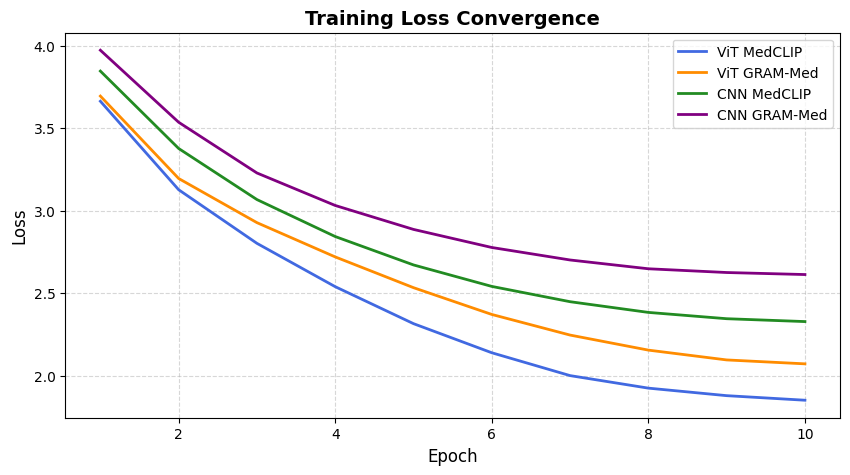

In [16]:
if loaded_successfully:
    plt.figure(figsize=(10, 5))
    
    styles = {
        "vit_medclip": {"label": "ViT MedCLIP", "color": "royalblue", "linestyle": "-"},
        "vit_gram": {"label": "ViT GRAM-Med", "color": "darkorange", "linestyle": "-"},
        "cnn_medclip": {"label": "CNN MedCLIP", "color": "forestgreen", "linestyle": "-"},
        "cnn_gram": {"label": "CNN GRAM-Med", "color": "purple", "linestyle": "-"}
    }
    
    for key, style in styles.items():
        if key in histories:
            epochs = [x["epoch"] for x in histories[key]]
            losses = [x["train_loss"] for x in histories[key]]
            plt.plot(epochs, losses, label=style["label"], color=style["color"], linestyle=style["linestyle"], linewidth=2)
            
    plt.title("Training Loss Convergence", fontsize=14, fontweight='bold')
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


### 4.3 Semantic Retrieval Performance @5 Over Time
We track the development of the Image-to-Text and Text-to-Image Semantic Recall & Precision @5 across epochs. These metrics evaluate the model's capability to align and retrieve correct medical entities and concepts over time.


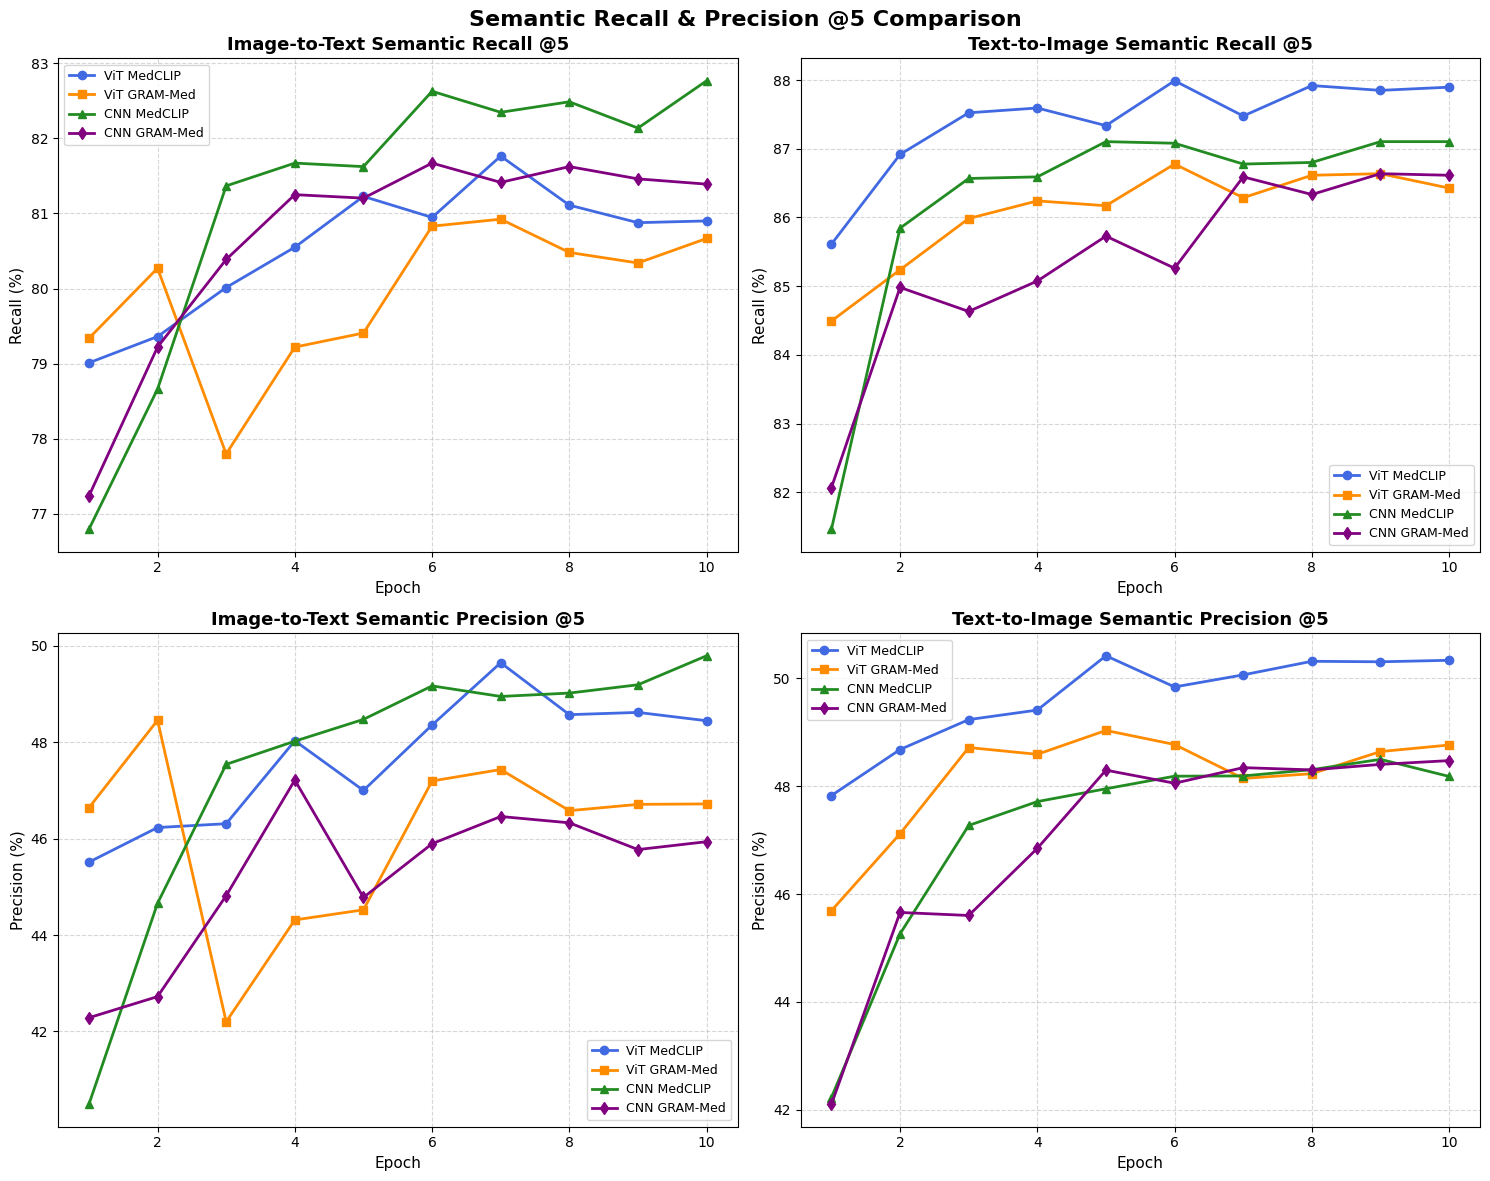

In [17]:
if loaded_successfully:
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    
    styles = {
        "vit_medclip": {"label": "ViT MedCLIP", "color": "royalblue", "marker": "o"},
        "vit_gram": {"label": "ViT GRAM-Med", "color": "darkorange", "marker": "s"},
        "cnn_medclip": {"label": "CNN MedCLIP", "color": "forestgreen", "marker": "^"},
        "cnn_gram": {"label": "CNN GRAM-Med", "color": "purple", "marker": "d"}
    }
    
    grid = [
        {"ax": axs[0, 0], "key": "i2t_SemR@5", "title": "Image-to-Text Semantic Recall @5", "ylabel": "Recall (%)"},
        {"ax": axs[0, 1], "key": "t2i_SemR@5", "title": "Text-to-Image Semantic Recall @5", "ylabel": "Recall (%)"},
        {"ax": axs[1, 0], "key": "i2t_SemP@5", "title": "Image-to-Text Semantic Precision @5", "ylabel": "Precision (%)"},
        {"ax": axs[1, 1], "key": "t2i_SemP@5", "title": "Text-to-Image Semantic Precision @5", "ylabel": "Precision (%)"}
    ]
    
    for item in grid:
        ax = item["ax"]
        key = item["key"]
        for model_key, style in styles.items():
            if model_key in histories:
                epochs = [x["epoch"] for x in histories[model_key]]
                values = [x.get(key, 0.0) * 100 for x in histories[model_key]]
                ax.plot(epochs, values, label=style["label"], color=style["color"], 
                        marker=style["marker"], linewidth=2, markersize=6)
        ax.set_title(item["title"], fontsize=13, fontweight='bold')
        ax.set_xlabel("Epoch", fontsize=11)
        ax.set_ylabel(item["ylabel"], fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.5)
        
    plt.suptitle("Semantic Recall & Precision @5 Comparison", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


### 4.4 Semantic Retrieval Performance @10 Over Time
We also analyze Semantic Recall & Precision @10 over time, demonstrating how robustly each model retrieves correct categories when allowed a larger candidate pool.


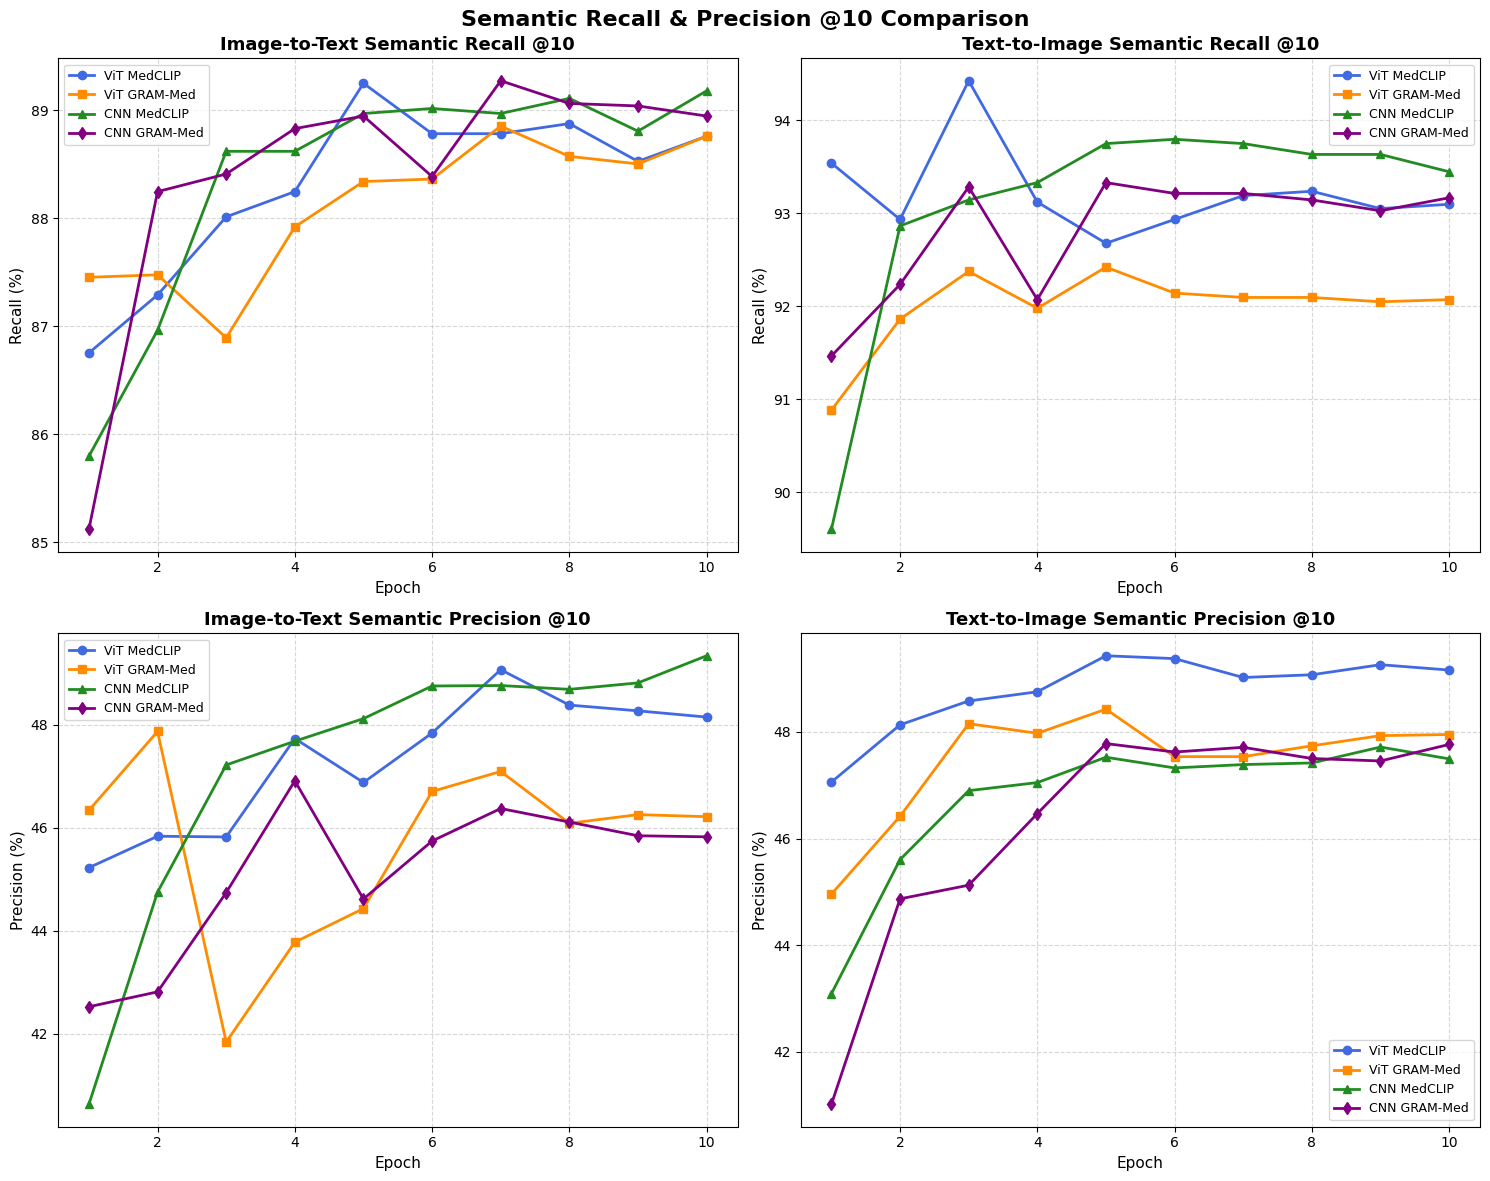

In [18]:
if loaded_successfully:
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    
    styles = {
        "vit_medclip": {"label": "ViT MedCLIP", "color": "royalblue", "marker": "o"},
        "vit_gram": {"label": "ViT GRAM-Med", "color": "darkorange", "marker": "s"},
        "cnn_medclip": {"label": "CNN MedCLIP", "color": "forestgreen", "marker": "^"},
        "cnn_gram": {"label": "CNN GRAM-Med", "color": "purple", "marker": "d"}
    }
    
    grid = [
        {"ax": axs[0, 0], "key": "i2t_SemR@10", "title": "Image-to-Text Semantic Recall @10", "ylabel": "Recall (%)"},
        {"ax": axs[0, 1], "key": "t2i_SemR@10", "title": "Text-to-Image Semantic Recall @10", "ylabel": "Recall (%)"},
        {"ax": axs[1, 0], "key": "i2t_SemP@10", "title": "Image-to-Text Semantic Precision @10", "ylabel": "Precision (%)"},
        {"ax": axs[1, 1], "key": "t2i_SemP@10", "title": "Text-to-Image Semantic Precision @10", "ylabel": "Precision (%)"}
    ]
    
    for item in grid:
        ax = item["ax"]
        key = item["key"]
        for model_key, style in styles.items():
            if model_key in histories:
                epochs = [x["epoch"] for x in histories[model_key]]
                values = [x.get(key, 0.0) * 100 for x in histories[model_key]]
                ax.plot(epochs, values, label=style["label"], color=style["color"], 
                        marker=style["marker"], linewidth=2, markersize=6)
        ax.set_title(item["title"], fontsize=13, fontweight='bold')
        ax.set_xlabel("Epoch", fontsize=11)
        ax.set_ylabel(item["ylabel"], fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.5)
        
    plt.suptitle("Semantic Recall & Precision @10 Comparison", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


## 🛑 5. Limitations and Reflections
- **Hardware Limitations**: This experiment required small batch sizes and the use of *Gradient Checkpointing* due to VRAM constraints. Training robust VLMs typically requires extensive GPU clusters to fully benefit from Contrastive Losses.


## 📚 6. References
1. **MedCLIP Paper**: Wang, Z., et al. "MedCLIP: Contrastive Learning from Unpaired Medical Images and Text." (2022).
2. **GRAM Framework**: Barbetta, F. et al. "Generative Representation Alignment for Medical domains." (GitHub Repository: [BarbettaFrancesco/medical-gram-clip](https://github.com/BarbettaFrancesco/medical-gram-clip)).
3. **Dataset**: [MIMIC-CXR Database](https://physionet.org/content/mimic-cxr/2.0.0/), PhysioNet.
